In [1]:
import numpy as np
import sleap
import matplotlib.pyplot as plt
import sys, os
sys.path.append('../..')
from python.postprocess import *
from python.animation import get_all_untracked_points_from_lbfs, get_each_edge_length, get_all_untracked_points
from eval.eval import *
from python.dataset_conversion import *
from src.data_loader import *

In [2]:
# original_dataset = sleap.load_file('/home/mingxiao/Desktop/jellyfish/video/video_1_clips/manual_5min_c0.slp')
# original_dataset = sleap.load_file('/home/mingxiao/Desktop/jellyfish/video/video_1_clips/correction_test/a1_1h_1m_simplemax.slp')
original_dataset = sleap.load_file('/home/mingxiao/Desktop/jellyfish/video/video_1_clips/correction_test/a1_1h_20s_no_scores_corrected.slp')
original_dataset

Labels(labeled_frames=3000, videos=1, skeletons=1, tracks=0)

In [3]:
results_affix = ['m11t1', 'm11t2', 'm11t3', 'm11t4']
all_predicted_pointss = []
results_dir = '../results/r8/'
existing_results = os.listdir(results_dir)
for affix in results_affix:
    print(f'affix: {affix}')
    denoised_coords = np.load(os.path.join(results_dir, f'prediction_{affix}.npy'))
    print(denoised_coords.shape)
    if f'predicted_dataset_{affix}.slp' not in existing_results:
    # if True:
        predicted_dataset = multi_model_dataset_with_points(original_dataset, denoised_coords, 
                                                            with_score=False, add_track=True)
        predicted_dataset.save(os.path.join(results_dir, f'predicted_dataset_{affix}.slp'))
    all_predicted_pointss.append(denoised_coords)

affix: m11t1
(3000, 17, 2)
Tentacle count: 17


affix: m11t2
(3000, 17, 2)
Tentacle count: 17
affix: m11t3
(3000, 17, 2)
Tentacle count: 17
affix: m11t4
(3000, 17, 2)
Tentacle count: 17


In [4]:
corrected_points_path = '/home/mingxiao/Desktop/jellyfish/video/video_1_clips/manual_5min_c0_tracked_points.npy'
y_true = np.load(corrected_points_path)
print(y_true.shape)

(9000, 17, 2)


In [4]:
corrected_dataset_path = '/home/mingxiao/Desktop/jellyfish/video/video_1_clips/correction_test/a1_1h_20s_no_scores_corrected.slp'
corrected_dataset = sleap.load_file(corrected_dataset_path)
gt_pts = get_all_untracked_points(corrected_dataset, interpolate=False, use_labeled_only=True)

all_untracked_points shape: (3000, 17, 2)


3000it [00:02, 1034.78it/s]

Missing point count: 0
reorder_idx.shape: (17,)


In [5]:
def get_matching_nn_dist(pred_pts, gt_pts, non_missing_mask=None,frame_cnt=3000):
    pt_cnt = pred_pts.shape[1]
    matching_nn_dist = np.zeros((frame_cnt, pt_cnt))
    if non_missing_mask is None:
        non_missing_mask = get_missing_count(pred_pts) == 0
        
    for i in range(frame_cnt):
        non_missing_indices = np.where(non_missing_mask[i])[0]
        matching_queue = [] # (dist, pt_idx, nn_idx)
        for j in non_missing_indices:
            all_dists = np.linalg.norm(pred_pts[i, j] - gt_pts[i, :], axis=-1)
            nn_idx = np.argmin(all_dists)
            matching_queue.append((all_dists[nn_idx], j, nn_idx))
        matching_queue.sort(key=lambda x: x[0])
        
        used_nn_idx = set()
        for dist, pt_idx, nn_idx in matching_queue:
            if nn_idx in used_nn_idx:
                matching_nn_dist[i, pt_idx] = np.nan
            else:
                used_nn_idx.add(nn_idx)
                matching_nn_dist[i, pt_idx] = dist
                
    return matching_nn_dist


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Create sample data (replace these with your actual data)
frame_cnt = 3000
time = np.arange(frame_cnt)  # Time points
pred_pts = all_predicted_pointss[3][:frame_cnt].copy()
non_missing_mask = get_missing_count(pred_pts) == 0
pred_pts[~non_missing_mask] = np.nan
x_coords = pred_pts[:, :, 0]
y_coords = pred_pts[:, :, 1]
# non_missing_mask = get_missing_count(pred_pts) == 0
error_signal = get_matching_nn_dist(pred_pts, gt_pts, non_missing_mask)

# Create figure and subplots
fig, axes = plt.subplots(17, 1, figsize=(12, 4*17))
fig.tight_layout(pad=3.0)

# Plot data for each point
for i in range(17):
    # Create twin axis for error signal
    ax2 = axes[i].twinx()
    
    # Plot coordinates on left y-axis
    l1, = axes[i].plot(time, x_coords[:, i], 'b-', label='x')
    l2, = axes[i].plot(time, y_coords[:, i], 'g-', label='y')
    
    # Plot error on right y-axis
    l3, = ax2.plot(time, error_signal[:, i], 'r-', label='error')
    
    # Set labels and title
    axes[i].set_xlabel('Time (frames)')
    axes[i].set_ylabel('Coordinates (pixels)')
    ax2.set_ylabel('Error (pixels)')
    axes[i].set_title(f'Point {i+1}')
    
    # Add legend
    lines = [l1, l2, l3]
    labels = [l.get_label() for l in lines]
    axes[i].legend(lines, labels, loc='upper right')
    
    # Set different colors for left and right y-axis labels
    axes[i].yaxis.label.set_color('black')
    ax2.yaxis.label.set_color('red')

plt.show()

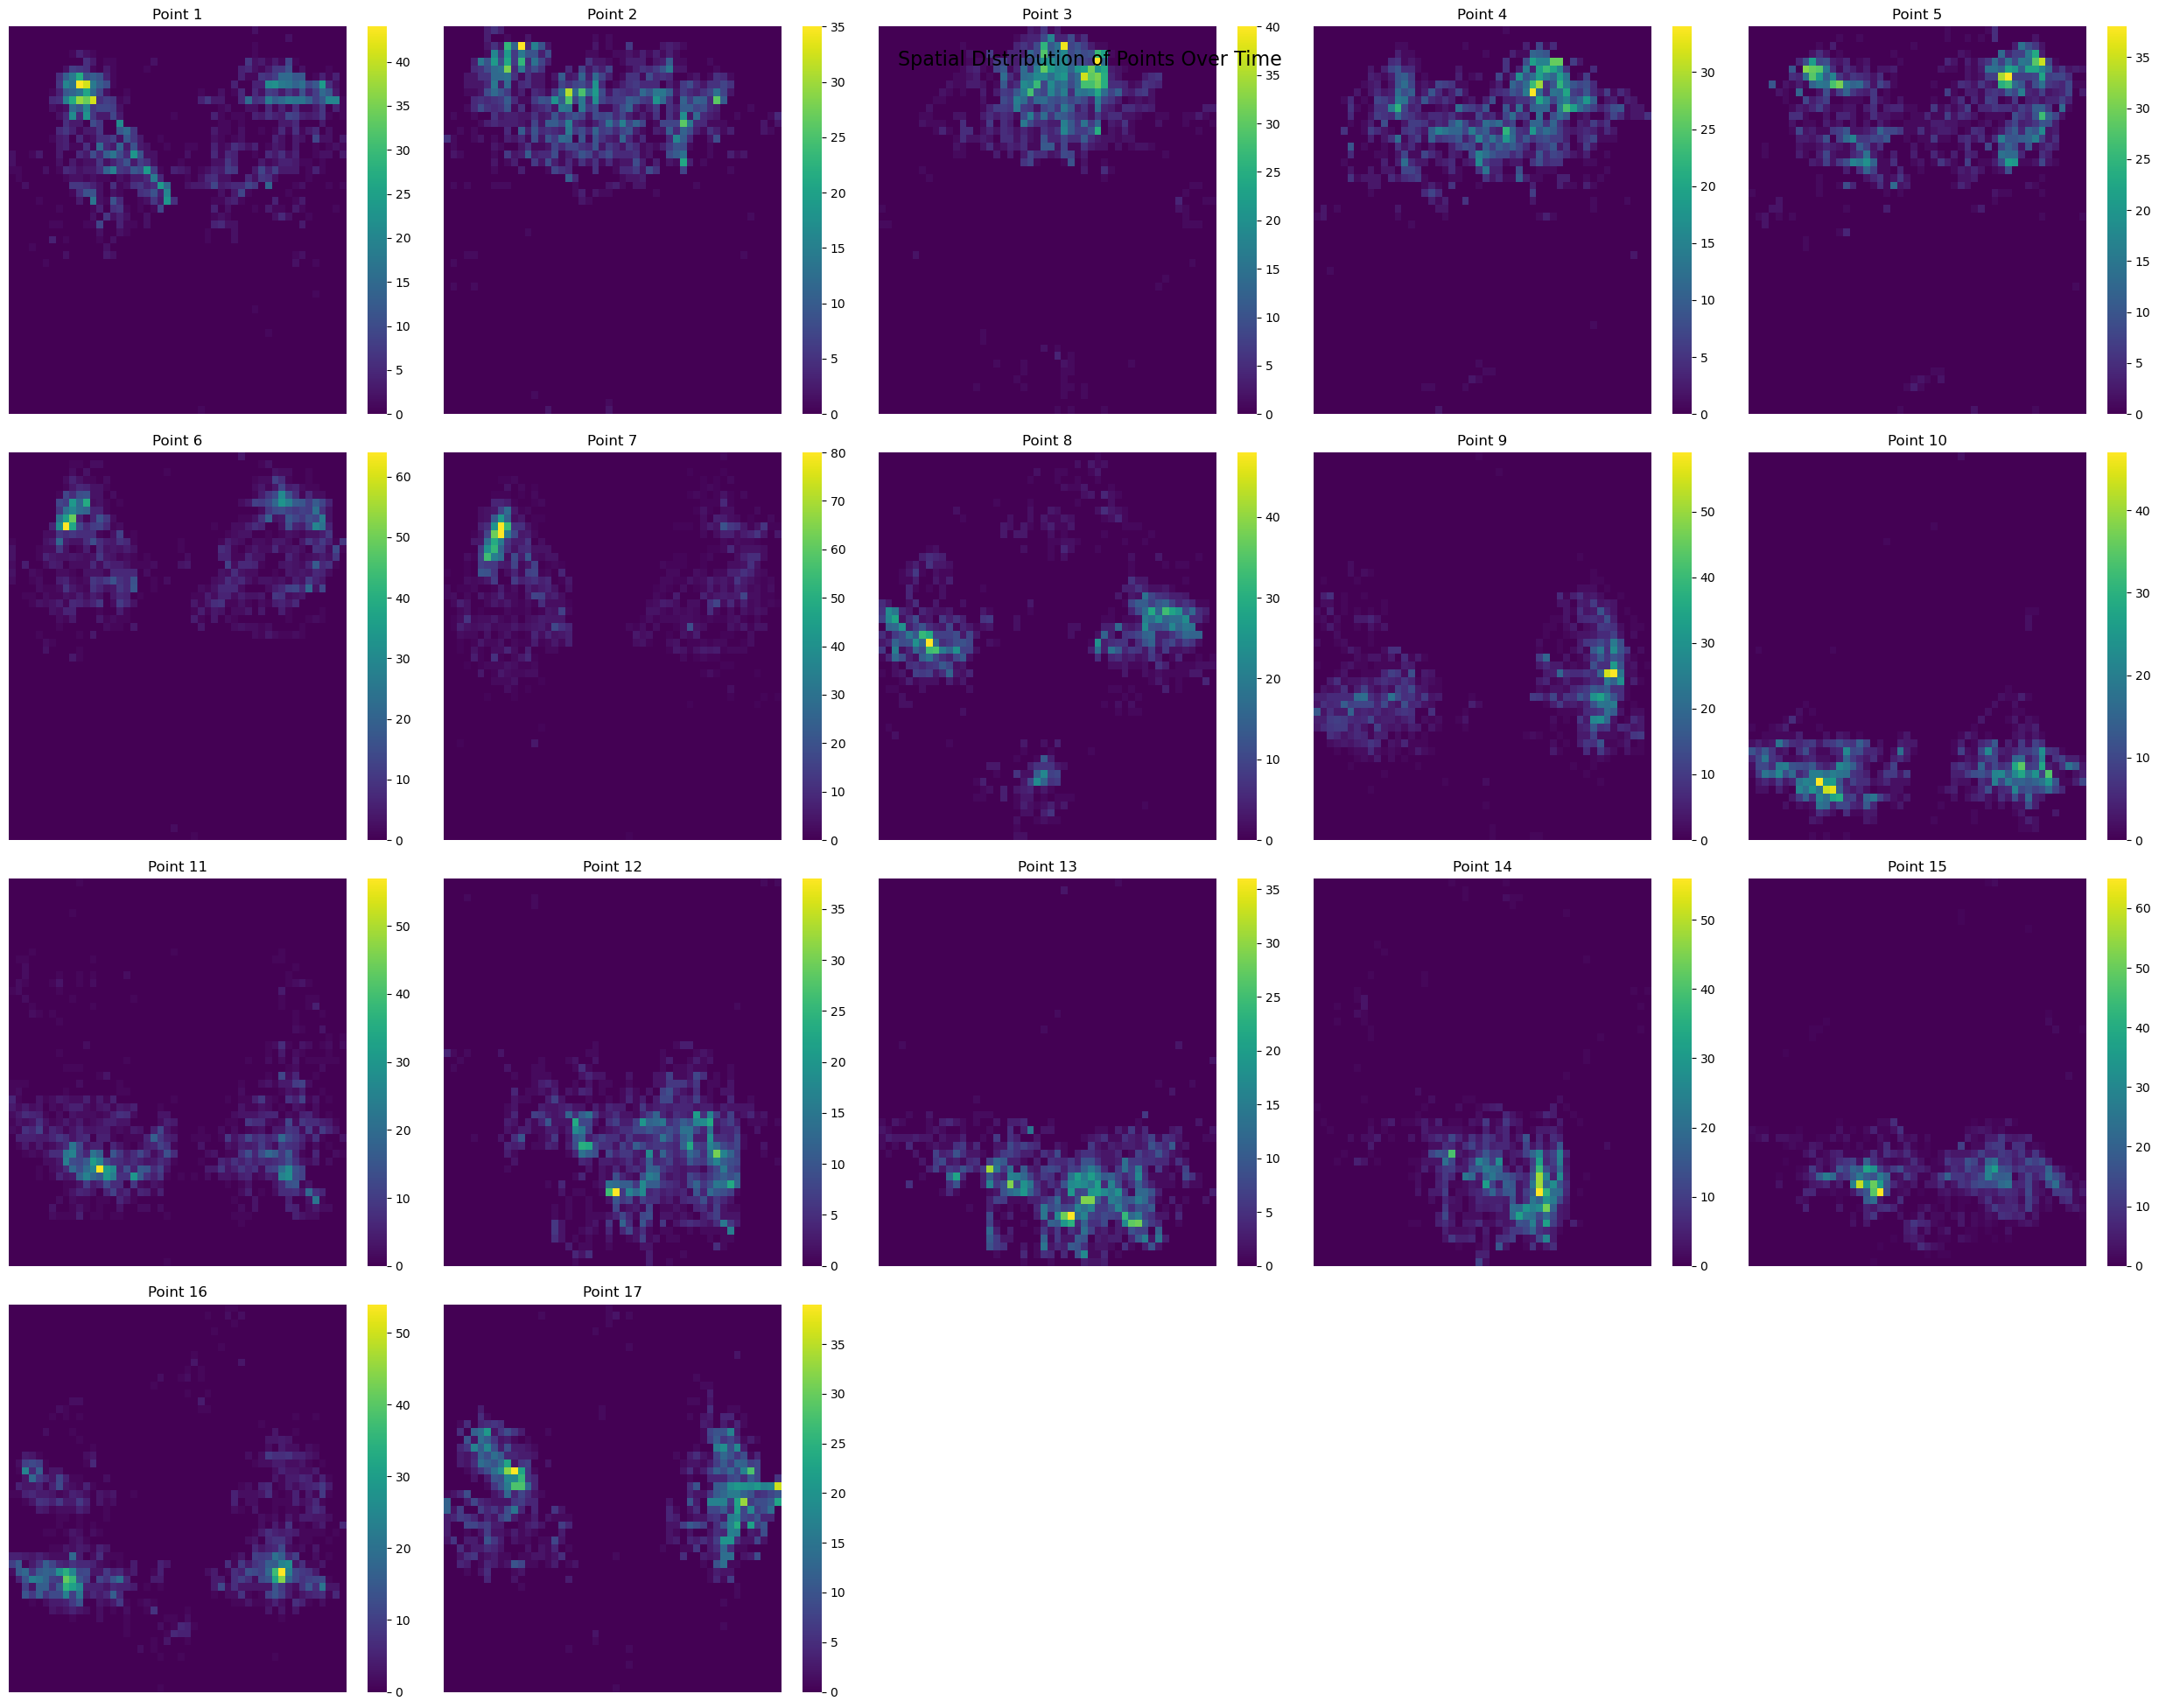

In [24]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Sample data (replace with your actual coordinates)
# points = np.random.randn(1000, 17, 2)  # (time, point_id, xy)
points = gt_pts[:]

# Create figure with 5x4 subplot grid
fig, axes = plt.subplots(4, 5, figsize=(25, 20))
fig.suptitle('Spatial Distribution of Points Over Time', fontsize=16, y=0.95)

# Flatten axes for easier iteration
axes_flat = axes.flatten()

# Create heatmaps for each point
for i in range(17):
    ax = axes_flat[i]
    
    # Get x and y coordinates for this point
    x = points[:, i, 0]
    y = points[:, i, 1]
    
    # Create 2D histogram
    heatmap, xedges, yedges = np.histogram2d(x, y, bins=50)
    
    # Plot heatmap
    sns.heatmap(heatmap.T, ax=ax, cmap='viridis')
    
    # Set title and labels
    ax.set_title(f'Point {i+1}')
    # ax.set_xlabel('X coordinate')
    # ax.set_ylabel('Y coordinate')
    ax.set_xlabel('')
    ax.set_ylabel('')
    
    # Remove ticks
    ax.set_xticks([])
    ax.set_yticks([])

# Remove empty subplots
for i in range(17, 20):
    fig.delaxes(axes_flat[i])

plt.tight_layout()
plt.show()

find 2 nearest neighbors over a sliding window 

use large window, find where it's expanded, assign order based on nearest neighbor

In [8]:
def get_diff(y_true, predicted_points, frames=3000):
    diff = np.sum(np.linalg.norm(y_true[:frames] - predicted_points[:frames], axis=-1)) / (frames * 17)
    return diff

for affix, predicted_points in zip(results_affix, all_predicted_pointss):
    diff = get_diff(gt_pts, predicted_points)
    print(f'{affix}: {diff:.4f}')


m10t1: 33.4205
m10t2: 33.4451
m11t1: 33.4595
m11t2: 33.3243


In [2]:
c0_dataset_path = '/home/mingxiao/Desktop/jellyfish/video/video_1_clips/manual_5min_c0.slp'
c0_dataset = sleap.load_file(c0_dataset_path)
print(c0_dataset)

Labels(labeled_frames=9000, videos=1, skeletons=1, tracks=17)


In [5]:
c0_points = get_all_tracked_points(original_dataset, reorder=False, interpolate=False, start_idx=0, min_score=0.6)
print(c0_points.shape)

all_tracked_points shape: (9000, 17, 2)
First non missing frame idx: 0
Missing point count: 7440
(9000, 17, 2)


In [4]:
c0_tracking_dataset = dataset_with_new_points(original_dataset, c0_points, node_name='tb', handle_first_frame=False, start_idx=0)
c0_tracking_dataset.save('/home/mingxiao/Desktop/jellyfish/video/video_1_clips/v2_c0_training.slp')

missing_pt_cnt: 7440


# generate animations

In [4]:
corrected_dataset_path = '/home/mingxiao/Desktop/jellyfish/video/video_1_clips/correction_test/a1_1h_20s_corrected_with_scores_simplemax.slp'
corrected_dataset = sleap.load_file(corrected_dataset_path)
print(corrected_dataset)
gt_pts = get_all_tracked_points(corrected_dataset, interpolate=False, use_labeled_only=False, reorder=False, start_idx=0)

Labels(labeled_frames=3000, videos=1, skeletons=1, tracks=17)
all_tracked_points shape: (3000, 17, 2)
First non missing frame idx: 0
Missing point count: 0


In [5]:
vid_path = '/home/mingxiao/Desktop/jellyfish/video/video_1_clips/animal_1_1h_20s.mp4'
vid = video_loader(vid_path)

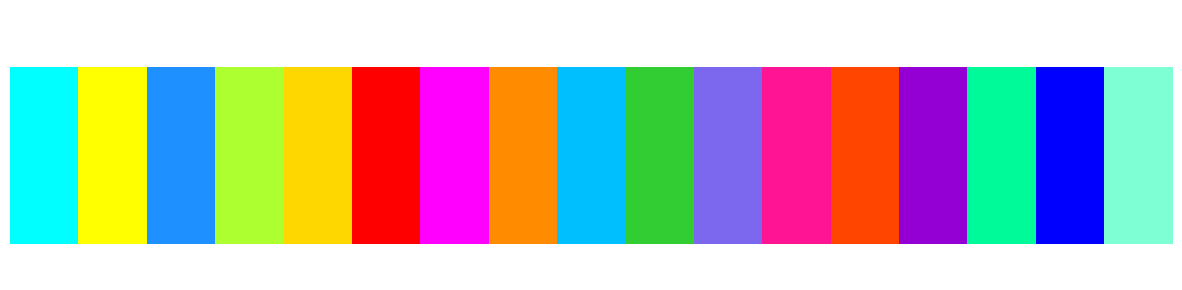

In [6]:
colors = get_tb_colors()
visualize_color_palette(colors)

In [7]:
def align_pts_order(pred_pts, gt_pts, frame_idx=0):
    from scipy.optimize import linear_sum_assignment
    
    pred_pts = pred_pts[frame_idx, :, :2]
    gt_pts = gt_pts[frame_idx, :, :2]
    
    # Compute cost matrix (pairwise distances between all pred and gt points)
    cost_matrix = np.zeros((len(pred_pts), len(gt_pts)))
    for i, pred_pt in enumerate(pred_pts):
        for j, gt_pt in enumerate(gt_pts):
            cost_matrix[i, j] = np.linalg.norm(pred_pt - gt_pt)
    
    # Use Hungarian algorithm to find optimal matching
    row_ind, col_ind = linear_sum_assignment(cost_matrix)
    
    # Create mapping array initialized with -1
    id_mapping = np.full(len(pred_pts), -1)
    
    # Fill in the optimal assignments
    for pred_idx, gt_idx in zip(row_ind, col_ind):
        id_mapping[pred_idx] = gt_idx
        
    return id_mapping

In [29]:
trial_cnt = 1000
test_pts = gt_pts[0]
poly_order = poly_4(test_pts)
for _ in range(trial_cnt):
    poly_order_test = poly_4(test_pts)
    assert np.all(poly_order == poly_order_test), 'poly_order is not consistent'

In [8]:
def polygon_correction_with_points(all_tracked_points, polygon_constructor=poly_4, return_indices=False):
    id_mapping = get_id_mapping_array(all_tracked_points)
    id_mapping = id_mapping.copy()
    frame_cnt = all_tracked_points.shape[0]
    idx_range = np.arange(all_tracked_points.shape[1])

    for frame_idx in range(1, frame_cnt):
        curr_frame_pts = all_tracked_points[frame_idx]
        polygon_order = polygon_constructor(curr_frame_pts)
        prev_frame_indices = id_mapping[frame_idx-1]
        best_shift = find_best_roll(curr_frame_pts[polygon_order], all_tracked_points[frame_idx-1][prev_frame_indices])
        shifted_indices = np.roll(polygon_order, best_shift, axis=0)
        id_mapping[frame_idx] = idx_range[shifted_indices]

    corrected_coords = get_corrected_coords(all_tracked_points, id_mapping)
    if return_indices:
        return corrected_coords, id_mapping
    else:
        return corrected_coords

In [41]:
pred_simplemax_pts = np.load('/home/mingxiao/Desktop/jellyfish/video/video_1_clips/correction_test/a1_1h_20s_pred_simplemax_pts_avg_flow_interpolated.npy')

all_pred_pts_corrected = []
for i, affix in tqdm(zip(range(len(all_predicted_pointss)), results_affix)):
    curr_pred_pts = all_predicted_pointss[i].copy()
    curr_pred_pts_corrected = align_pts_order(curr_pred_pts, gt_pts, return_corrected_pts=True)
    curr_pred_pts[0] = curr_pred_pts_corrected
    curr_pred_pts_poly_corrected = polygon_correction_with_points(curr_pred_pts)
    corrected_path = os.path.join(results_dir, f'prediction_{affix}_corrected.npy')
    all_pred_pts_corrected.append(curr_pred_pts_poly_corrected)
    np.save(corrected_path, curr_pred_pts_poly_corrected)
    # all_pred_pts_corrected.append(curr_pred_pts_corrected)
all_pred_pts_corrected = np.array(all_pred_pts_corrected)

0it [00:00, ?it/s]

5it [00:35,  7.10s/it]


In [9]:
input_path = '/home/mingxiao/Desktop/jellyfish/video/video_1_clips/correction_test/a1_1h_20s_pred_simplemax_pts_preprocessed.npy'
input_pts = np.load(input_path)
print(input_pts.shape)

(3000, 17, 2)


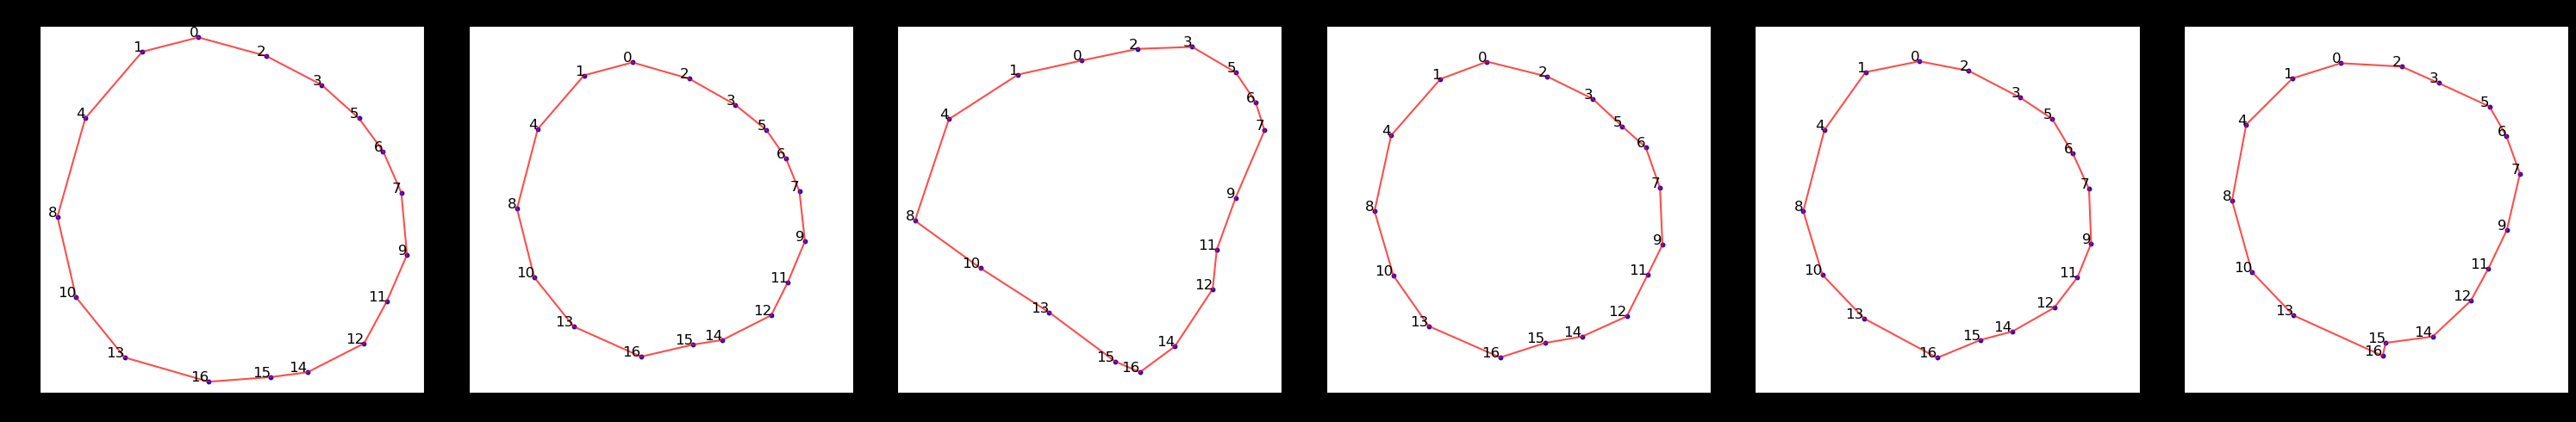


Total edge lengths:
poly_1: 231.042
poly_2: 230.237
poly_3: 232.581
poly_4: 231.650
poly_5: 232.209
poly_6: 233.768


In [42]:
poly_pts = [pred_simplemax_pts[0]] + [pred_pts[0] for pred_pts in all_predicted_pointss]
# poly_pts = [gt_pts[0]] + all_pred_pts_corrected
poly_pts = np.array(poly_pts)
plot_multiframe_polygons(poly_pts)

In [ ]:
anim_path = '/home/mingxiao/Desktop/animation/ae_r8_m11_eval.mp4'
pred_simplemax_pts = np.load('/home/mingxiao/Desktop/jellyfish/video/video_1_clips/correction_test/a1_1h_20s_pred_simplemax_pts_avg_flow_interpolated.npy')
all_predicted_pts = all_predicted_pointss
poly_order = poly_4(pred_simplemax_pts[0])
pred_simplemax_pts = pred_simplemax_pts[:, poly_order]
frames = 3000
pts_lst = [pred_simplemax_pts[:frames]] + [input_pts[:frames]] + [pp[:frames] for pp in all_predicted_pts]
label_lst = ['original'] + ['input'] + results_affix
animate_tb(pts_lst, label_lst=label_lst, bg_video=vid[:frames], bg_video_start_idx=0, output_path=anim_path, 
           fps=10, tb_colors=colors, subplot_shape=(2, 3))

INFO:matplotlib.animation:Animation.save using <class 'matplotlib.animation.FFMpegWriter'>
INFO:matplotlib.animation:figure size in inches has been adjusted from 26.099999999999998 x 17.0 to 26.1 x 17.0
INFO:matplotlib.animation:MovieWriter._run: running command: ffmpeg -f rawvideo -vcodec rawvideo -s 2610x1700 -pix_fmt rgba -r 10 -loglevel error -i pipe: -vcodec h264 -pix_fmt yuv420p -y /home/mingxiao/Desktop/animation/ae_r8_m11_eval.mp4
